# ECS assessment

This notebook combines process understanding, the historical record, and paleoclimate evidence to estimate the net radiative feedback from modern CO$_2$ doubling, $\lambda_{\mathrm{2xCO_2}}$, and equilibrium climate sensitivity (ECS). 

The inputs and probability model are all in this notebook; no data downloads or companion files are needed.

Create the environment using conda or mamba,

```bash
conda env create -f ecs.yml
conda activate ecs
```
then open this notebook and run the cells in order.

Use the Python kernel from `ecs`. The environment includes CmdStan and its compiler. Sampling takes a few minutes; each chain has a live progress bar. Results, input snapshots, and figures go into `ecs_assess_results/` in the working directory. 

The short input sections for each line of evidence are the main places to make changes to assumptions.

In [21]:
import json
import logging
import sys
from datetime import datetime
from pathlib import Path

import cmdstanpy
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import Rectangle
import numpy as np
import pandas as pd
from IPython.display import Code, display
from scipy.integrate import trapezoid
from scipy.stats import gaussian_kde, lognorm, norm, skewnorm, truncnorm

## find the CmdStan installation supplied by the environment
env_bin = Path(sys.executable).resolve().parent
try:
    cmdstanpy.cmdstan_path()
except ValueError:
    cmdstanpy.set_cmdstan_path(str(env_bin / "cmdstan"))
env_cxx = env_bin / "x86_64-conda-linux-gnu-g++"
cpp_options = {"CXX": str(env_cxx)} if env_cxx.exists() else {}

plt.rcParams.update({
    ## "font.family": "serif", "font.serif": ["STIXGeneral"],
    ## "mathtext.fontset": "stix", "font.size": 10, "pdf.fonttype": 42,
    "figure.dpi": 140, "savefig.dpi": 300, 
})
print("CmdStanPy", cmdstanpy.__version__, "| CmdStan", cmdstanpy.cmdstan_version())
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

CmdStanPy 1.2.1 | CmdStan (2, 39)


## Global inputs

In [22]:
## forcing is in W m-2; feedbacks are in W m-2 K-1; temperatures are in K
erf_2x, sig_erf_2x = 3.93, 0.29
co2_pi = 284.7  ## ppm
lambda_lower, lambda_upper = -100.0, -0.01  ## limit sampling range

## alternative prior: log(|lambda|) has this mean and standard deviation
lognormal_mu = np.log(2.02815)  ## about 0.707
lognormal_sigma = 1.24420

sampling = dict(
    chains=4, parallel_chains=4, iter_warmup=1_000, iter_sampling=5_000,
    adapt_delta=0.95, max_treedepth=12, seed=20250812,
    show_progress=True, show_console=False, refresh=500,  ## live progress for each chain
)
likelihood_settings = dict(grid_points=1_000, mc_draws=30_000, seed=20250813)
save_figures = True
output_dir = Path("ecs_assess_results")

def finish_figure(fig, name):
    fig.tight_layout()
    if save_figures:
        folder = output_dir / "figures"
        folder.mkdir(parents=True, exist_ok=True)
        fig.savefig(folder / f"{name}.pdf", bbox_inches="tight")
    plt.show()

def sum_independent(*terms):
    ## each term is (mean, 1 sigma); independent variances add
    return sum(t[0] for t in terms), np.sqrt(sum(t[1]**2 for t in terms))

def product_independent(a, b):
    ## product variance: uncertainty in b, uncertainty in a, and their product
    mu = a[0] * b[0]
    variance = a[0]**2*b[1]**2 + b[0]**2*a[1]**2 + a[1]**2*b[1]**2
    return mu, np.sqrt(variance)

def input_table(rows):
    return pd.DataFrame.from_dict(rows, orient="index", columns=["mean", "1 sigma"])

## Process evidence

Each pair below gives a mean and $1\sigma$. We add the component means and combine their uncertainties in quadrature, assuming independent errors. The cloud values come from the assessed study mixtures; the non-cloud uncertainties are added below without rounding.

To change the cloud assessment by assigning different weights to various studies, use the external cloud_assess notebook. Then enter your changes here.

In [23]:
## cloud feedbacks: high altitude, high amount + optical depth, marine low, land, other
## (mean, 1sigma)
highcloud_alt = (0.24180, 0.125454)
highcloud_amt_optdepth = (0.01350, 0.114829)
marine_lowcloud = (0.30975, 0.211013)
landcloud = (0.08, 0.08)
unassessed_cloud = (0.0, 0.10)
## add the five cloud components; add their independent variances
cloud_total = sum_independent(
    highcloud_alt, highcloud_amt_optdepth, marine_lowcloud,
    landcloud, unassessed_cloud,
)

## non-cloud
## add intermodel, kernel, stratospheric, and extra structural uncertainty in quadrature
planck = (-3.23, np.sqrt(0.04**2 + 0.10**2 + 0 + 0))
## LR+WV mean: tropospheric + stratospheric feedback
lrwv = (1.25 + 0.02, np.sqrt(0.09**2 + 0.08**2 + 0.10**2 + 0.09**2))
surface_albedo = (0.39, np.sqrt(0.09**2 + 0.08**2 + 0. + 0.09**2))
unassessed_noncloud = (0.0, 0.16)
## add Planck, LR+WV, albedo, and other feedbacks, then combine with clouds
noncloud_total = sum_independent(planck, lrwv, surface_albedo, unassessed_noncloud)
process_total = sum_independent(cloud_total, noncloud_total)

process_components = {
    "High cloud: altitude": highcloud_alt,
    "High cloud: amount + tau": highcloud_amt_optdepth,
    "Low cloud: marine": marine_lowcloud,
    "Land cloud": landcloud, "Other cloud": unassessed_cloud,
    "Total cloud": cloud_total, "Planck": planck, "LR + WV": lrwv,
    "Surface albedo": surface_albedo, "Other": unassessed_noncloud,
    "Total feedback": process_total,
}
print(f"Total process feedback: {process_total[0]} ± {process_total[1]} W m-2 K-1")

Total process feedback: -0.9249499999999998 ± 0.4269085282891406 W m-2 K-1


SW20         IPCC AR6         This assessment  \
                          mean 1 sigma     mean 1 sigma            mean   
High cloud: altitude      0.20    0.10     0.22    0.12         0.24180   
High cloud: amount + tau -0.20    0.20    -0.15    0.20         0.01350   
Low cloud: marine         0.37    0.22     0.27    0.20         0.30975   
Land cloud                0.08    0.08     0.08    0.08         0.08000   
Other cloud                NaN     NaN      NaN     NaN         0.00000   
Total cloud               0.45    0.34     0.42    0.33         0.64505   
Planck                   -3.20    0.10    -3.22    0.12        -3.23000   
LR + WV                   1.15    0.18     1.30    0.12         1.27000   
Surface albedo            0.30    0.15     0.35    0.15         0.39000   
Other                     0.00    0.15    -0.01    0.16         0.00000   
Total feedback           -1.30    0.44    -1.16    0.43        -0.92495   
ERF 2xCO2 (W m-2)         4.00    0.30     3.93    0.29         3.93000   

                                    
                           1 sigma  
High cloud: altitude      0.125454  
High cloud: amount + tau  0.114829  
Low cloud: marine         0.211013  
Land cloud                0.080000  
Other cloud               0.100000  
Total cloud               0.299751  
Planck                    0.107703  
LR + WV                   0.180555  
Surface albedo            0.150333  
Other                     0.160000  
Total feedback            0.426909  
ERF 2xCO2 (W m-2)         0.290000

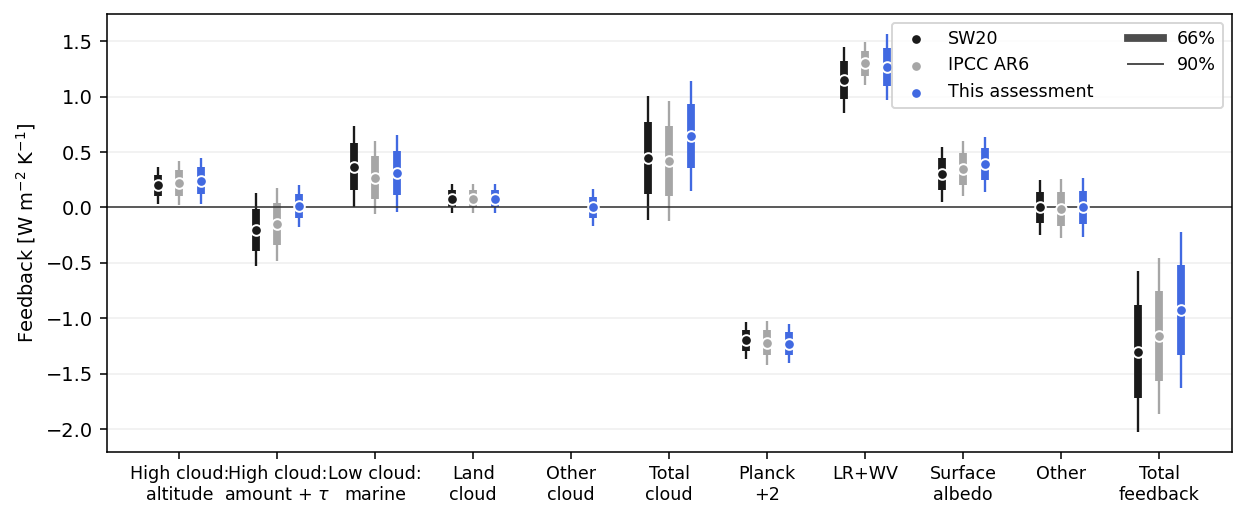

In [24]:
## comparison values from the paper; these do not enter the probability model
process_comparisons = {
    "SW20": list(zip(
        [0.20, -0.20, 0.37, 0.08, np.nan, 0.45, -3.20, 1.15, 0.30, 0.00, -1.30],
        [0.10, 0.20, 0.22, 0.08, np.nan, 0.34, 0.10, 0.18, 0.15, 0.15, 0.44])),
    "IPCC AR6": list(zip(
        [0.22, -0.15, 0.27, 0.08, np.nan, 0.42, -3.22, 1.30, 0.35, -0.01, -1.16],
        [0.12, 0.20, 0.20, 0.08, np.nan, 0.33, 0.12, 0.12, 0.15, 0.16, 0.43])),
    "This assessment": list(process_components.values()),
}
process_table = pd.concat({
    name: input_table(dict(zip(process_components, values)))
    for name, values in process_comparisons.items()
}, axis=1)
process_table.loc["ERF 2xCO2 (W m-2)"] = [4.00, 0.30, 3.93, 0.29, erf_2x, sig_erf_2x]
display(process_table)

labels = ["High cloud:\naltitude", "High cloud:\namount + $\\tau$",
          "Low cloud:\nmarine", "Land\ncloud", "Other\ncloud", "Total\ncloud",
          "Planck\n+2", "LR+WV", "Surface\nalbedo", "Other", "Total\nfeedback"]
fig, ax = plt.subplots(figsize=(9, 3.8))
colors = ["0.1", "0.65", "royalblue"]
for offset, color, (name, values) in zip([-0.22, 0, 0.22], colors, process_comparisons.items()):
    means, sigmas = np.array(values).T
    means[6] += 2  ## shift Planck for plotting only
    x = np.arange(len(means)) + offset
    for probability, width in [(0.95, 1.2), (0.83, 4)]:
        halfwidth = norm.ppf(probability) * sigmas
        ax.vlines(x, means-halfwidth, means+halfwidth, color=color, lw=width)
    ax.scatter(x, means, color=color, edgecolor="white", s=30, zorder=3, label=name)
ax.axhline(0, color="0.2", lw=0.8)
ax.set(xticks=np.arange(len(labels)), xticklabels=labels,
       ylabel=r"Feedback [W m$^{-2}$ K$^{-1}$]")
ax.tick_params(axis="x", labelsize=9)
ax.grid(axis="y", alpha=0.2)
handles, names = ax.get_legend_handles_labels()
handles += [Line2D([], [], color="0.3", lw=4), Line2D([], [], color="0.3", lw=1)]
ax.legend(handles, names + ["66%", "90%"], ncol=2, fontsize=9)
finish_figure(fig, "fig_process_components")

## Historical evidence

The instrumental inputs are 2006–2024 minus 1850–1900 means. 21st-century Trends are for 2006–2024, **per decade**. $\Delta\lambda=\lambda_{\mathrm{2xCO_2}}-\lambda$ accounts for differences between each period's feedback and the feedback from modern CO$_2$ doubling.

The calculations below add the independent uncertainty terms in quadrature, as described in the paper, and retain their full precision.

In [ ]:
## instrumental era
## T uncertainty: observational + internal variability
T_instrumental = (1.089, np.sqrt(0.08**2 + 0.098**2))
## N mean: 2006–2024 minus preindustrial
## N uncertainty: recent observations + preindustrial + internal variability
N_instrumental = (0.91 - 0.10, np.sqrt(0.14**2 + 0.12**2 + 0.051**2))
f_CO2_instrumental = 1.80 / erf_2x  ## fixed ratio to CO2-doubling forcing
F_aer_instrumental = (-0.24 - 0.73, 0.342)  ## ERFari + ERFaci; spread from paired IGCC members
F_other_instrumental = (1.820, 0.175)

## skew normal: location, scale, shape (these are not the mean and 1 sigma)
## for a normal distribution, set a=0, loc=mean, and scale=1 sigma
## e.g. dict(loc=0.57, scale=0.33, a=0); the input names and Stan code stay the same
dlambda_instrumental = dict(loc=0.976, scale=0.523, a=-3.7573)

## recent trends
## T uncertainty: observational + internal variability
T_trend = (0.312, np.sqrt(0.016**2 + 0.0694**2))
## N uncertainty: regression standard error + structural uncertainty
N_trend = (0.452, np.sqrt(0.161**2 + 0.10**2))
dlambda_trend = (0.0, 0.30)
f_CO2_trend = 0.329 / erf_2x  ## fixed ratio to CO2-doubling forcing, per decade
F_aer_trend = (0.200, 0.143)  ## IGCC ERFari + ERFaci
F_other_trend = (0.150, 0.016)

## paired IGCC forcing errors across the two periods
## units: (W m-2) * (W m-2 decade-1); CO2 covariance comes from shared F2x
cov_aerosol = -0.0247083552
cov_other = 0.00108444987
display(pd.Series({
    "aerosol correlation": cov_aerosol / (F_aer_instrumental[1] * F_aer_trend[1]),
    "other forcing correlation": cov_other / (F_other_instrumental[1] * F_other_trend[1]),
    "instrumental dlambda 5th percentile": skewnorm.ppf(.05, **dlambda_instrumental),
    "instrumental dlambda median": skewnorm.median(**dlambda_instrumental),
    "instrumental dlambda 95th percentile": skewnorm.ppf(.95, **dlambda_instrumental),
}, name="value"))

aerosol correlation                    -0.505221
other forcing correlation               0.387304
instrumental dlambda 5th percentile    -0.049061
instrumental dlambda median             0.623480
instrumental dlambda 95th percentile    1.026205
Name: value, dtype: float64

In [ ]:
historical_tables = {}
for name, T, N, f_co2, Faer, Fother in [
    ("Instrumental", T_instrumental, N_instrumental, f_CO2_instrumental,
     F_aer_instrumental, F_other_instrumental),
    ("Trend (per decade)", T_trend, N_trend, f_CO2_trend, F_aer_trend, F_other_trend),
]:
    co2_forcing = (f_co2 * erf_2x, abs(f_co2) * sig_erf_2x)
    ## non-CO2 = aerosol + other; total = CO2 + aerosol + other
    ## add the independent variances for each forcing total
    historical_tables[name] = input_table({
        "T": T, "N": N, "f_CO2 (fixed)": (f_co2, 0),
        "dlambda (mean, 1 sigma)": (
            (skewnorm.mean(**dlambda_instrumental), skewnorm.std(**dlambda_instrumental))
            if name == "Instrumental" else dlambda_trend),
        "F_aer": Faer, "F_other": Fother, "F_CO2 (derived)": co2_forcing,
        "F_nonCO2 (derived)": sum_independent(Faer, Fother),
        "F_total (derived)": sum_independent(co2_forcing, Faer, Fother),
    })
display(pd.concat(historical_tables, axis=1))

Instrumental           Trend (per decade)          
                                mean   1 sigma               mean   1 sigma
T                           1.089000  0.126507           0.312000  0.071221
N                           0.810000  0.191314           0.452000  0.189528
f_CO2 (fixed)               0.458015  0.000000           0.083715  0.000000
dlambda (mean, 1 sigma)     0.572744  0.333037           0.000000  0.300000
F_aer                      -0.970000  0.342000           0.200000  0.143000
F_other                     1.820000  0.175000           0.150000  0.016000
F_CO2 (derived)             1.800000  0.132824           0.329000  0.024277
F_nonCO2 (derived)          0.850000  0.384173           0.350000  0.143892
F_total (derived)           2.650000  0.406487           0.679000  0.145926

## Paleo evidence

All anomalies are relative to preindustrial conditions. We use the Last Glacial Maximum (LGM) and the Pliocene's KM5c interglacial. The LGM and Pliocene $\Delta\lambda$ errors have estimated error correlation of 0.5. Other errors are independent apart from the common $F_{\mathrm{2xCO_2}}$.

In [27]:
## LGM
## (mean, 1sigma)
T_LGM = (-6.0, 0.9)
N_LGM = (-0.03, 0.03)
dlambda_LGM = (-0.35, 0.35)
f_CO2_LGM = (-0.55, 0.04) ## ratio of LGM CO2 forcing to 2xCO2

## CH4: SARF times (ERF adjustment + associated ozone and stratospheric water vapor)
## N2O: SARF times its ERF adjustment
## ice sheets: midpoint of two ERF estimates; intermodel variance + 50% extra variance
lgm_forcings = {
    "CH4": (-0.38 * (0.86 + 0.45), 0.05),
    "N2O": (-0.28 * 1.07, 0.10),
    "ice sheets": ((-3.2 - 2.1) / 2, np.sqrt(0.85**2 + 0.5 * 0.85**2)),
    "vegetation": (-0.50, 0.50),
    "aerosols": (-0.50, 1.46),
}
## add CH4, N2O, ice sheets, vegetation, and aerosols; add their independent variances
F_other_LGM = sum_independent(*lgm_forcings.values())
F_CO2_LGM = product_independent(f_CO2_LGM, (erf_2x, sig_erf_2x))
lgm_table = input_table({
    "T (K)": T_LGM, "N (W m-2)": N_LGM,
    "dlambda (W m-2 K-1)": dlambda_LGM, "f_CO2": f_CO2_LGM,
    **{f"F_{k} (W m-2)": v for k, v in lgm_forcings.items()},
    "F_nonCO2 (derived)": F_other_LGM,
    "F_CO2 (derived)": F_CO2_LGM,
    ## total = CO2 + all non-CO2 forcings
    "F_total (derived)": sum_independent(F_CO2_LGM, F_other_LGM),
})
display(lgm_table)

,mean,1 sigma
T (K),-6.0000,0.900000
N (W m-2),-0.0300,0.030000
dlambda (W m-2 K-1),-0.3500,0.350000
f_CO2,-0.5500,0.040000
F_CH4 (W m-2),-0.4978,0.050000
F_N2O (W m-2),-0.2996,0.100000
F_ice sheets (W m-2),-2.6500,1.041033
F_vegetation (W m-2),-0.5000,0.500000
F_aerosols (W m-2),-0.5000,1.460000
F_nonCO2 (derived),-4.4474,1.864899


In [28]:
## Pliocene (mean, 1sigma)
T_plio = (3.9, 0.9)
N_plio = (0.0, 0.05)
dlambda_plio = (-0.38, 0.40)
## CO2 uncertainty: proxy error + an equal amount of additional error variance
CO2_plio = (391.0, np.sqrt(15.0**2 + 15.0**2))
f_otherGHG_plio = (0.43, 0.08)  ## other-GHG forcing / CO2 forcing
rho_dlambda_LGM_plio = 0.5

## three AGCM estimates; assign their range as 1 sigma until more estimates are available
ice_veg_topo = (np.mean([1.26, 1.66, 1.86]), 1.86 - 1.26)
aerosol_plio = (0.10, 0.60)
## non-GHG forcing: ice/vegetation/topography + aerosols; independent variances add
F_plio_nonGHG = (
    ice_veg_topo[0] + aerosol_plio[0],
    np.sqrt(ice_veg_topo[1]**2 + aerosol_plio[1]**2),
)

## concentration-to-forcing relation from Meinshausen et al. (2020),
## with preindustrial N2O = 273 ppb; a common ERF adjustment cancels in the ratio
def co2_sarf(co2_ppm):
    c = np.asarray(co2_ppm, dtype=float)
    a, b, d, ref = -2.4785e-7, 7.5906e-4, 5.2488, 277.15
    alpha = np.where(c <= ref, d, np.where(
        c < ref - b/(2*a), d + a*(c-ref)**2 + b*(c-ref), d - b*b/(4*a)))
    return (alpha - 2.1492e-3*np.sqrt(273.0)) * np.log(c/ref)

def plio_co2_ratio(co2_ppm, pi):
    return (co2_sarf(co2_ppm) - co2_sarf(pi)) / (co2_sarf(2*pi) - co2_sarf(pi))

## Monte Carlo for this summary table; Stan samples CO2 directly below
## keep concentrations positive and use a fixed seed for reproducibility
co2_draws = truncnorm.rvs(
    -CO2_plio[0]/CO2_plio[1], np.inf, loc=CO2_plio[0], scale=CO2_plio[1],
    size=100_000, random_state=np.random.default_rng(20250814),
)
ratios = plio_co2_ratio(co2_draws, co2_pi)
ratio_mu = ratios.mean()
ratio_sd = ratios.std(ddof=1)
F_CO2_plio = product_independent((ratio_mu, ratio_sd), (erf_2x, sig_erf_2x))
F_otherGHG_plio = product_independent(F_CO2_plio, f_otherGHG_plio)
## total GHG = CO2 * (1 + other-GHG ratio); these two forcings are correlated
F_GHG_plio = product_independent(F_CO2_plio, (1+f_otherGHG_plio[0], f_otherGHG_plio[1]))
plio_table = input_table({
    "T (K)": T_plio, "N (W m-2)": N_plio,
    "dlambda (W m-2 K-1)": dlambda_plio, "CO2 (ppm)": CO2_plio,
    "f_otherGHG": f_otherGHG_plio, "F_ice,veg,topo": ice_veg_topo,
    "F_aerosol": aerosol_plio, "F_nonGHG": F_plio_nonGHG,
    "f_CO2 (derived)": (ratio_mu, ratio_sd), "F_CO2 (derived)": F_CO2_plio,
    "F_otherGHG (derived)": F_otherGHG_plio,
    ## total = CO2 + other GHGs + non-GHG forcing
    "F_total (derived)": sum_independent(F_GHG_plio, F_plio_nonGHG),
})
display(plio_table)

,mean,1 sigma
T (K),3.900000,0.900000
N (W m-2),0.000000,0.050000
dlambda (W m-2 K-1),-0.380000,0.400000
CO2 (ppm),391.000000,21.213203
f_otherGHG,0.430000,0.080000
"F_ice,veg,topo",1.593333,0.600000
F_aerosol,0.100000,0.600000
F_nonGHG,1.693333,0.848528
f_CO2 (derived),0.445780,0.078435
F_CO2 (derived),1.751914,0.335032


## Collect inputs in a dictionary

`inputs` is the complete dictionary passed to Stan. `mu_` means the central estimate and `sig_` means $1\sigma$. `f_CO2_instrumental` and `f_CO2_trend` are fixed ratios to CO$_2$-doubling forcing (the trend ratio is per decade). A switch of 1 includes that line of evidence; 0 leaves it out. Prior choices are `uniform_lambda`, `lognormal_lambda`, and `uniform_ECS`. As described in the paper, `uniform_ECS` is only included for reference; it should not be used as a valid prior.

For a permanent revision, change the values above and rerun from there. For a temporary test, pass the parameters to `run_case`, e.g. `run_case("low_pliocene_co2", input_updates={"mu_CO2_plio": 250.0})`. Each run saves its full inputs and leaves the baseline dictionary unchanged.

In [ ]:
prior_types = {"uniform_ECS": 0, "uniform_lambda": 1, "lognormal_lambda": 2}
inputs = {
    "erf_2x": erf_2x, "sig_F2xCO2": sig_erf_2x, "CO2_PI": co2_pi,
    "lambda_lower": lambda_lower, "lambda_upper": lambda_upper,
    "lognormal_mu": lognormal_mu, "lognormal_sigma": lognormal_sigma,
    "lambda_prior_type": prior_types["uniform_lambda"],
    "include_process": 1, "include_instrumental": 1, "include_trend": 1,
    "include_lgm": 1, "include_pliocene": 1,
    "mu_lambda": process_total[0], "sig_lambda": process_total[1],
    "f_CO2_instrumental": f_CO2_instrumental, "f_CO2_trend": f_CO2_trend,
    "loc_dlambda_instrumental": dlambda_instrumental["loc"],
    "scale_dlambda_instrumental": dlambda_instrumental["scale"],
    "shape_dlambda_instrumental": dlambda_instrumental["a"],
    "cov_F_anthro_aerosol_instrumental_trend": cov_aerosol,
    "cov_F_other_instrumental_trend": cov_other,
    "rho_dlambda_LGM_plio": rho_dlambda_LGM_plio,
}
## expand each (mean, 1 sigma) pair into two clearly named Stan inputs
for name, (mu, sig) in {
    "T_instrumental": T_instrumental, "N_instrumental": N_instrumental,
    "F_anthro_aerosol_instrumental": F_aer_instrumental,
    "F_other_instrumental": F_other_instrumental,
    "T_trend": T_trend, "N_trend": N_trend, "dlambda_trend": dlambda_trend,
    "F_anthro_aerosol_trend": F_aer_trend, "F_other_trend": F_other_trend,
    "T_LGM": T_LGM, "N_LGM": N_LGM, "dlambda_LGM": dlambda_LGM,
    "f_CO2_LGM": f_CO2_LGM, "F_other_LGM": F_other_LGM,
    "T_plio": T_plio, "N_plio": N_plio, "dlambda_plio": dlambda_plio,
    "CO2_plio": CO2_plio, "f_otherGHG": f_otherGHG_plio,
    "F_plio_nonGHG": F_plio_nonGHG,
}.items():
    inputs[f"mu_{name}"] = float(mu)
    inputs[f"sig_{name}"] = float(sig)

print(f"{len(inputs)} inputs, including the prior and evidence switches")

63 inputs, including the prior and evidence switches


# Probability model

After changing an input above, rerun the input dictionary and the calculations below. Only changes to the `stan` text require re-running the cell below. CmdStan needs a file to compile, so this cell writes the embedded model into the results folder automatically.

The common physical model is

$$N = F + (\lambda_{\mathrm{2xCO_2}}-\Delta\lambda)T + \epsilon,
\qquad \mathrm{ECS}=-F_{\mathrm{2xCO_2}}/\lambda_{\mathrm{2xCO_2}}.$$

Stan tries combinations of the uncertain quantities and compares the resulting energy imbalances with their assessed distributions. A statement such as `T_LGM ~ normal(mu_T_LGM, sig_T_LGM)` supplies the assessed uncertainty in LGM temperature. The `if` statements include or omit the evidence. 

The baseline is uniform in $\lambda_\mathrm{2xCO_2}$ between the bounds specified above. The alternative lognormal prior is on $|\lambda|$.

In [ ]:
## a clean, syntax-highlighted version of the stan code is in the following cell
stan_code = r"""
functions {
    // helper calculations used by the model below

    // CO2 forcing relation from Meinshausen et al. (2020), also used in Python
    real co2_sarf(real c) {
        real a   = -2.4785e-7;
        real b   = 7.5906e-4;
        real d   = 5.2488;
        real ref = 277.15;
        real alpha;

        if (c <= ref)
            alpha = d;
        else if (c < ref - b / (2 * a))
            alpha = d + a * square(c - ref) + b * (c - ref);
        else
            alpha = d - square(b) / (4 * a);

        return (alpha - 2.1492e-3 * sqrt(273.0)) * log(c / ref);
    }

    // variances on the diagonal; shared error covariance off diagonal
    matrix pair_covariance(real sig1, real sig2, real covariance) {
        matrix[2, 2] result;
        result[1, 1] = square(sig1);
        result[2, 2] = square(sig2);
        result[1, 2] = covariance;
        result[2, 1] = covariance;

        return result;
    }
}

data {
    // fixed inputs from the Python dictionary; these are prescribed (not sampled)
    // mu_ is a central estimate; sig_ is 1 sigma; Python checks positive uncertainties

    // choose the prior and which lines of evidence to include
    int<lower=0, upper=2>   lambda_prior_type;
    int<lower=0, upper=1>   include_process;
    int<lower=0, upper=1>   include_instrumental;
    int<lower=0, upper=1>   include_trend;
    int<lower=0, upper=1>   include_lgm;
    int<lower=0, upper=1>   include_pliocene;

    // feedback bounds and alternative lognormal prior
    // Python also checks lambda_lower < lambda_upper < 0
    real<upper=0>           lambda_lower;
    real<upper=0>           lambda_upper;
    real                    lognormal_mu;
    real                    lognormal_sigma;

    // common CO2 forcing and process feedback assessment
    real                    erf_2x;
    real                    sig_F2xCO2;
    real<lower=0>           CO2_PI;
    real                    mu_lambda;
    real                    sig_lambda;

    // instrumental era: temperature and energy imbalance
    real                    mu_T_instrumental;
    real                    sig_T_instrumental;
    real                    mu_N_instrumental;
    real                    sig_N_instrumental;

    // instrumental forcing components
    real                    f_CO2_instrumental;
    real                    mu_F_anthro_aerosol_instrumental;
    real                    sig_F_anthro_aerosol_instrumental;
    real                    mu_F_other_instrumental;
    real                    sig_F_other_instrumental;

    // instrumental pattern effect: skew-normal location, scale, and shape
    real                    loc_dlambda_instrumental;
    real                    scale_dlambda_instrumental;
    real                    shape_dlambda_instrumental;

    // 21st-century trends, units per decade
    real                    mu_T_trend;
    real                    sig_T_trend;
    real                    mu_N_trend;
    real                    sig_N_trend;

    real                    f_CO2_trend;
    real                    mu_F_anthro_aerosol_trend;
    real                    sig_F_anthro_aerosol_trend;
    real                    mu_F_other_trend;
    real                    sig_F_other_trend;

    real                    mu_dlambda_trend;
    real                    sig_dlambda_trend;

    // forcing error covariances between the two historical periods
    real                    cov_F_anthro_aerosol_instrumental_trend;
    real                    cov_F_other_instrumental_trend;

    // LGM
    real                    mu_T_LGM;
    real                    sig_T_LGM;
    real                    mu_N_LGM;
    real                    sig_N_LGM;

    real                    mu_F_other_LGM;
    real                    sig_F_other_LGM;
    real                    mu_f_CO2_LGM;
    real                    sig_f_CO2_LGM;

    real                    mu_dlambda_LGM;
    real                    sig_dlambda_LGM;

    // Pliocene
    real                    mu_T_plio;
    real                    sig_T_plio;
    real                    mu_N_plio;
    real                    sig_N_plio;

    real                    mu_CO2_plio;
    real                    sig_CO2_plio;
    real                    mu_F_plio_nonGHG;
    real                    sig_F_plio_nonGHG;
    real                    mu_f_otherGHG;
    real                    sig_f_otherGHG;

    real                    mu_dlambda_plio;
    real                    sig_dlambda_plio;

    // shared uncertainty in the two paleo pattern effects
    real<lower=-1, upper=1> rho_dlambda_LGM_plio;
}

transformed data {
    // calculate the covariance matrices once, before sampling
    matrix[2, 2] cov_aerosol = pair_covariance(
        sig_F_anthro_aerosol_instrumental, sig_F_anthro_aerosol_trend,
        cov_F_anthro_aerosol_instrumental_trend);

    matrix[2, 2] cov_other   = pair_covariance(
        sig_F_other_instrumental, sig_F_other_trend,
        cov_F_other_instrumental_trend);

    matrix[2, 2] cov_paleo   = pair_covariance(
        sig_dlambda_LGM, sig_dlambda_plio,
        rho_dlambda_LGM_plio * sig_dlambda_LGM * sig_dlambda_plio);
}

parameters {
    // uncertain quantities sampled by Stan; distributions are assigned below

    // common forcing and feedback
    real<lower=1e-6>                             F_2xCO2;
    real<lower=lambda_lower, upper=lambda_upper> lamb;

    // instrumental era
    real T_instrumental;
    real dlambda_instrumental;
    real F_anthro_aerosol_instrumental;
    real F_other_instrumental;

    // 21st-century trends
    real T_trend;
    real dlambda_trend;
    real F_anthro_aerosol_trend;
    real F_other_trend;

    // LGM
    real T_LGM;
    real dlambda_LGM;
    real F_other_LGM;
    real f_CO2_LGM;

    // Pliocene
    real          T_plio;
    real          dlambda_plio;
    real<lower=0> CO2_plio;
    real          F_plio_nonGHG;
    real          f_otherGHG;
}

transformed parameters {
    // derive ECS, forcings, and energy imbalances from each sampled combination
    real ECS                = -F_2xCO2 / lamb;

    // fixed CO2 ratios multiply the same sampled CO2-doubling forcing
    // historical forcing = CO2 + aerosols + other forcing
    real F_CO2_instrumental = f_CO2_instrumental * F_2xCO2;
    real F_CO2_trend        = f_CO2_trend        * F_2xCO2;

    real F_instrumental     = F_CO2_instrumental
                              + F_anthro_aerosol_instrumental + F_other_instrumental;
    real F_trend            = F_CO2_trend + F_anthro_aerosol_trend + F_other_trend;

    // paleo CO2 forcings share the same sampled forcing from CO2 doubling
    real F_CO2_LGM          = f_CO2_LGM * F_2xCO2;
    real f_CO2_plio         = (co2_sarf(CO2_plio) - co2_sarf(CO2_PI))
                              / (co2_sarf(2 * CO2_PI) - co2_sarf(CO2_PI));
    real F_CO2_plio         = f_CO2_plio * F_2xCO2;

    // N = F + R: total forcing plus the radiative response to temperature
    // each period's feedback is lamb minus its pattern effect, dlambda
    real N_instrumental     = F_instrumental
                              + (lamb - dlambda_instrumental) * T_instrumental;

    real N_trend            = F_trend
                              + (lamb - dlambda_trend)        * T_trend;

    // LGM forcing = CO2 + other; Pliocene forcing = CO2 + other GHGs + non-GHGs
    real N_LGM              = F_CO2_LGM + F_other_LGM
                              + (lamb - dlambda_LGM)          * T_LGM;

    real N_plio             = F_CO2_plio * (1 + f_otherGHG) + F_plio_nonGHG
                              + (lamb - dlambda_plio)         * T_plio;
}

model {
    // "~" assigns an assessed distribution or compares a prediction with the evidence

    // common CO2 forcing and process feedback evidence
    F_2xCO2 ~ normal(erf_2x, sig_F2xCO2);

    if (include_process)
        lamb ~ normal(mu_lambda, sig_lambda);

    // prior 1 is uniform lamb within the bounds above; no extra term is needed
    // prior 0 reweights to uniform ECS; prior 2 is lognormal in |feedback|
    if (lambda_prior_type == 0)
        target += -2 * log(-lamb);
    else if (lambda_prior_type == 2)
        -lamb ~ lognormal(lognormal_mu, lognormal_sigma);

    // assessed historical temperatures
    T_instrumental ~ normal(mu_T_instrumental, sig_T_instrumental);
    T_trend        ~ normal(mu_T_trend,        sig_T_trend);

    // assessed historical pattern effects
    dlambda_instrumental ~ skew_normal(
        loc_dlambda_instrumental, scale_dlambda_instrumental, shape_dlambda_instrumental);
    dlambda_trend        ~ normal(mu_dlambda_trend, sig_dlambda_trend);

    // pair the historical forcing errors across periods
    [F_anthro_aerosol_instrumental, F_anthro_aerosol_trend]' ~ multi_normal(
        [mu_F_anthro_aerosol_instrumental, mu_F_anthro_aerosol_trend]', cov_aerosol);

    [F_other_instrumental, F_other_trend]' ~ multi_normal(
        [mu_F_other_instrumental, mu_F_other_trend]', cov_other);

    // assessed LGM temperature and forcings
    T_LGM       ~ normal(mu_T_LGM,       sig_T_LGM);
    F_other_LGM ~ normal(mu_F_other_LGM, sig_F_other_LGM);
    f_CO2_LGM   ~ normal(mu_f_CO2_LGM,   sig_f_CO2_LGM);

    // assessed Pliocene temperature, CO2 concentration, and other forcings
    T_plio        ~ normal(mu_T_plio,        sig_T_plio);
    CO2_plio      ~ normal(mu_CO2_plio,      sig_CO2_plio);
    f_otherGHG    ~ normal(mu_f_otherGHG,    sig_f_otherGHG);
    F_plio_nonGHG ~ normal(mu_F_plio_nonGHG, sig_F_plio_nonGHG);

    // pair the LGM and Pliocene pattern effects
    [dlambda_LGM, dlambda_plio]' ~ multi_normal(
        [mu_dlambda_LGM, mu_dlambda_plio]', cov_paleo);

    // compare each predicted imbalance with its assessed distribution
    // a switch of 0 omits that energy-budget constraint
    if (include_instrumental)
        N_instrumental ~ normal(mu_N_instrumental, sig_N_instrumental);

    if (include_trend)
        N_trend        ~ normal(mu_N_trend,        sig_N_trend);

    if (include_lgm)
        N_LGM          ~ normal(mu_N_LGM,          sig_N_LGM);

    if (include_pliocene)
        N_plio         ~ normal(mu_N_plio,         sig_N_plio);
}
"""


build_dir = output_dir / "build"
build_dir.mkdir(parents=True, exist_ok=True)
stan_file = build_dir / "ecs_assess.stan"
if not stan_file.exists() or stan_file.read_text() != stan_code:
    stan_file.write_text(stan_code)
model = cmdstanpy.CmdStanModel(stan_file=str(stan_file), cpp_options=cpp_options)

In [ ]:
## display the Stan model with nice formatting for ease of review
display(Code(stan_code, language="stan"))

functions {
    // helper calculations used by the model below

    // CO2 forcing relation from Meinshausen et al. (2020), also used in Python
    real co2_sarf(real c) {
        real a   = -2.4785e-7;
        real b   = 7.5906e-4;
        real d   = 5.2488;
        real ref = 277.15;
        real alpha;

        if (c <= ref)
            alpha = d;
        else if (c < ref - b / (2 * a))
            alpha = d + a * square(c - ref) + b * (c - ref);
        else
            alpha = d - square(b) / (4 * a);

        return (alpha - 2.1492e-3 * sqrt(273.0)) * log(c / ref);
    }

    // variances on the diagonal; shared error covariance off diagonal
    matrix pair_covariance(real sig1, real sig2, real covariance) {
        matrix[2, 2] result;
        result[1, 1] = square(sig1);
        result[2, 2] = square(sig2);
        result[1, 2] = covariance;
        result[2, 1] = covariance;

        return result;
    }
}

data {
    // fixed inputs from the Python dictionary; these are prescribed (not sampled)
    // mu_ is a central estimate; sig_ is 1 sigma; Python checks positive uncertainties

    // choose the prior and which lines of evidence to include
    int<lower=0, upper=2>   lambda_prior_type;
    int<lower=0, upper=1>   include_process;
    int<lower=0, upper=1>   include_instrumental;
    int<lower=0, upper=1>   include_trend;
    int<lower=0, upper=1>   include_lgm;
    int<lower=0, upper=1>   include_pliocene;

    // feedback bounds and alternative lognormal prior
    // Python also checks lambda_lower < lambda_upper < 0
    real<upper=0>           lambda_lower;
    real<upper=0>           lambda_upper;
    real                    lognormal_mu;
    real                    lognormal_sigma;

    // common CO2 forcing and process feedback assessment
    real                    erf_2x;
    real                    sig_F2xCO2;
    real<lower=0>           CO2_PI;
    real                    mu_lambda;
    real                    sig_lambda;

    // instrumental era: temperature and energy imbalance
    real                    mu_T_instrumental;
    real                    sig_T_instrumental;
    real                    mu_N_instrumental;
    real                    sig_N_instrumental;

    // instrumental forcing components
    real                    f_CO2_instrumental;
    real                    mu_F_anthro_aerosol_instrumental;
    real                    sig_F_anthro_aerosol_instrumental;
    real                    mu_F_other_instrumental;
    real                    sig_F_other_instrumental;

    // instrumental pattern effect: skew-normal location, scale, and shape
    real                    loc_dlambda_instrumental;
    real                    scale_dlambda_instrumental;
    real                    shape_dlambda_instrumental;

    // 21st-century trends, units per decade
    real                    mu_T_trend;
    real                    sig_T_trend;
    real                    mu_N_trend;
    real                    sig_N_trend;

    real                    f_CO2_trend;
    real                    mu_F_anthro_aerosol_trend;
    real                    sig_F_anthro_aerosol_trend;
    real                    mu_F_other_trend;
    real                    sig_F_other_trend;

    real                    mu_dlambda_trend;
    real                    sig_dlambda_trend;

    // forcing error covariances between the two historical periods
    real                    cov_F_anthro_aerosol_instrumental_trend;
    real                    cov_F_other_instrumental_trend;

    // LGM
    real                    mu_T_LGM;
    real                    sig_T_LGM;
    real                    mu_N_LGM;
    real                    sig_N_LGM;

    real                    mu_F_other_LGM;
    real                    sig_F_other_LGM;
    real                    mu_f_CO2_LGM;
    real                    sig_f_CO2_LGM;

    real                    mu_dlambda_LGM;
    real                    sig_dlambda_LGM;

    // Pliocene
    real        

## Calculate posterior distributions

The runner below saves each calculation in a new directory. Leaving out a line of evidence removes its energy-budget constraint; its remaining uncertain inputs still have proper distributions and integrate out. Correlated inputs retain the appropriate marginal distribution for the evidence that remains.

In [11]:
input_names = set(inputs)
results = {}

def validate_inputs(data):
    if set(data) != input_names:
        raise ValueError(f"Input keys differ: {set(data) ^ input_names}")
    if not all(np.isfinite(v) for v in data.values()):
        raise ValueError("Inputs must be finite")
    for name, value in data.items():
        if (name.startswith("sig_") or name in {"scale_dlambda_instrumental", "lognormal_sigma"}) and value <= 0:
            raise ValueError(f"{name} must be positive")
        if name.startswith("include_") and value not in (0, 1):
            raise ValueError(f"{name} must be 0 or 1")
    if data["lambda_prior_type"] not in prior_types.values():
        raise ValueError("Unknown prior choice")
    if not data["lambda_lower"] < data["lambda_upper"] < 0:
        raise ValueError("Feedback bounds must satisfy lower < upper < 0")
    if data["erf_2x"] <= 0 or data["CO2_PI"] <= 0:
        raise ValueError("The reference forcing and CO2 must be positive")
    for part in ("anthro_aerosol", "other"):
        sd1, sd2 = [data[f"sig_F_{part}_{period}"] for period in ("instrumental", "trend")]
        if abs(data[f"cov_F_{part}_instrumental_trend"]) >= sd1*sd2:
            raise ValueError(f"Invalid historical {part} forcing covariance")
    if abs(data["rho_dlambda_LGM_plio"]) >= 1:
        raise ValueError("Paleo pattern-effect correlation must lie between -1 and 1")

def run_case(name, input_updates=None, sampling_updates=None):
    ## apply temporary changes for this run; keep the baseline inputs unchanged
    data = {**inputs, **(input_updates or {})}
    validate_inputs(data)
    settings = {**sampling, **(sampling_updates or {})}
    folder = output_dir / f"{name}_{datetime.now():%Y%m%dT%H%M%S_%f}"
    folder.mkdir(parents=True)
    cmdstanpy.write_stan_json(str(folder / "inputs.json"), data)
    (folder / "model.stan").write_text(stan_code)
    (folder / "run.json").write_text(json.dumps({
        "sampling": settings, "cmdstanpy": cmdstanpy.__version__,
        "cmdstan": cmdstanpy.cmdstan_version(),
    }, indent=2))
    init = {name: data[f"mu_{name}"] for name in (
        "T_instrumental", "F_anthro_aerosol_instrumental", "F_other_instrumental",
        "T_trend", "F_anthro_aerosol_trend", "F_other_trend", "dlambda_trend",
        "T_LGM", "F_other_LGM", "f_CO2_LGM", "dlambda_LGM",
        "T_plio", "CO2_plio", "F_plio_nonGHG", "f_otherGHG", "dlambda_plio",
    )}
    init.update(F_2xCO2=data["erf_2x"], dlambda_instrumental=skewnorm.median(
        data["shape_dlambda_instrumental"], loc=data["loc_dlambda_instrumental"],
        scale=data["scale_dlambda_instrumental"]))
    ## start chains at different feedbacks within the chosen bounds
    initial_values = [{**init, "lamb": float(np.clip(
        -data["erf_2x"] / ecs, data["lambda_lower"]*0.99, data["lambda_upper"]*1.01))}
        for ecs in np.linspace(2.5, 5.0, settings["chains"])]
    print(name)
    fit = model.sample(data=data, inits=initial_values, output_dir=str(folder), **settings)
    summary = fit.summary()
    summary.to_csv(folder / "stan_summary.csv")
    method = fit.method_variables()
    diagnostics = {
        "divergences": int(method["divergent__"].sum()),
        "max treedepth hits": int((method["treedepth__"] >= settings["max_treedepth"]).sum()),
        "max R_hat": float(summary["R_hat"].max()),
        "min ESS_bulk": float(summary["ESS_bulk"].min()),
        "min ESS_tail": float(summary["ESS_tail"].min()),
    }
    entry = dict(data=data, fit=fit, summary=summary, diagnostics=diagnostics,
                 lamb=fit.stan_variable("lamb"), ECS=fit.stan_variable("ECS"), folder=folder)
    results[name] = entry
    print("ECS 5, 17, 50, 83, 95%:", np.quantile(entry["ECS"], [.05, .17, .5, .83, .95]))
    return entry

## baseline

In [12]:
baseline = run_case("baseline")
display(baseline["summary"].loc[["ECS", "lamb", "F_2xCO2"]])

baseline


17:42:39 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

17:42:45 - cmdstanpy - INFO - CmdStan done processing.


ECS 5, 17, 50, 83, 95%: [2.51401816 2.84292355 3.4505551  4.3200771  5.28167675]


,Mean,MCSE,StdDev,MAD,5%,50%,95%,ESS_bulk,ESS_tail,ESS_bulk/s,R_hat
ECS,3.61572,0.008699,0.912957,0.733361,2.51402,3.45056,5.281680,13279.6,11864.0,731.498,1.00016
lamb,-1.14125,0.002175,0.246592,0.246114,-1.54938,-1.13923,-0.737627,12818.1,10950.7,706.076,1.00007
F_2xCO2,3.92531,0.001579,0.280389,0.280485,3.46501,3.92418,4.386910,31630.9,14168.7,1742.370,1.00004


## leave-one-out tests and alternative priors

These runs omit each line separately, omit the two historical or two paleo lines together, and use each alternative prior. The lower-Pliocene-CO$_2$ example also shows how to change one input temporarily. Every case starts from the same baseline inputs.

Check the diagnostics before interpreting the results: we want no divergences or maximum-treedepth hits, R-hat close to 1 (preferably below 1.01), and enough effective samples to resolve the reported tails. Increase `iter_sampling` for more precise percentiles; persistent sampling problems need investigation.

In [13]:
case_updates = {
    "no_process": {"include_process": 0},
    "without_instrumental": {"include_instrumental": 0},
    "without_trend": {"include_trend": 0},
    "without_joint_historical": {"include_instrumental": 0, "include_trend": 0},
    "without_lgm": {"include_lgm": 0},
    "without_pliocene": {"include_pliocene": 0},
    "no_paleo": {"include_lgm": 0, "include_pliocene": 0},
    "lognormal_lambda": {"lambda_prior_type": prior_types["lognormal_lambda"]},
    "uniform_ECS": {"lambda_prior_type": prior_types["uniform_ECS"]},
}
for name, changes in case_updates.items():
    run_case(name, input_updates=changes)

## example: temporarily change the Pliocene CO2 estimate for one run
low_pliocene_co2 = run_case(
    "low_pliocene_co2", input_updates={"mu_CO2_plio": 250.0},
)

diagnostic_table = pd.DataFrame({name: r["diagnostics"] for name, r in results.items()}).T
display(diagnostic_table)
diagnostic_table.to_csv(output_dir / "diagnostics.csv")

17:42:46 - cmdstanpy - INFO - CmdStan start processing


no_process


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

...

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

17:44:00 - cmdstanpy - INFO - CmdStan done processing.


ECS 5, 17, 50, 83, 95%: [2.79712719 3.20589942 3.9854139  5.19200282 6.61038548]


,divergences,max treedepth hits,max R_hat,min ESS_bulk,min ESS_tail
baseline,0.0,0.0,1.00041,8388.09,10950.70
no_process,0.0,0.0,1.00073,8736.62,8559.07
without_instrumental,0.0,0.0,1.00052,8198.32,10032.70
without_trend,0.0,0.0,1.00053,8547.03,11356.20
without_joint_historical,0.0,0.0,1.00083,8977.33,10535.30
without_lgm,0.0,0.0,1.00039,8358.58,11628.40
without_pliocene,0.0,0.0,1.00087,8063.05,10727.20
no_paleo,0.0,0.0,1.00057,9394.93,8643.31
lognormal_lambda,0.0,0.0,1.00093,8905.64,11655.90
uniform_ECS,0.0,0.0,1.00107,7488.97,7915.94


## likelihoods

For each proposed feedback or ECS, we average the agreement with the evidence over the uncertain forcing and pattern effects. Temperature and additive Gaussian forcing errors can be integrated exactly: the variance of an energy-budget residual includes $\sigma_N^2+(\lambda-\Delta\lambda)^2\sigma_T^2+\sigma_F^2$. This avoids unnecessary Monte Carlo noise.

The joint historical calculation retains the aerosol and other-forcing covariance. The joint paleo calculation averages paired LGM and Pliocene contributions with correlated pattern effects. Both share the same CO$_2$ forcing draws. A joint likelihood therefore differs from the product of separately averaged likelihoods. Stan fits the full model directly; these curves help us see what each line contributes.

Each likelihood is scaled to its own maximum. ECS likelihoods substitute $\lambda=-F_{\mathrm{2xCO_2}}/\mathrm{ECS}$ for each forcing draw. They are likelihood functions, so there is no density-transformation factor. Posterior PDFs below do include that factor and are normalized over their full support, including the part outside the plot.

In [14]:
individual_evidence = ("Process", "Instrumental", "Trend", "LGM", "Pliocene")
evidence_colors = {
    "Process": "#4b57db", "Instrumental": "darkorange", "Trend": "tab:red",
    "Joint Historical": "orangered", "LGM": "cornflowerblue",
    "Pliocene": "darkgreen", "Joint Paleo": "mediumseagreen",
}

def normal_density(residual, variance):
    return np.exp(-0.5 * residual**2 / variance) / np.sqrt(2*np.pi*variance)

def paired_density(r1, r2, v1, v2, covariance):
    determinant = v1*v2 - covariance**2
    if np.any(determinant <= 0):
        raise ValueError("The residual covariance must be positive definite")
    quadratic = (v2*r1**2 - 2*covariance*r1*r2 + v1*r2**2) / determinant
    return np.exp(-0.5*quadratic) / (2*np.pi*np.sqrt(determinant))

def calculate_likelihoods(data, settings=None):
    validate_inputs(data)
    d = dict(data)
    cfg = {**likelihood_settings, **(settings or {})}
    n = int(cfg["mc_draws"])
    rng = np.random.default_rng(cfg["seed"])
    ## reuse the same draws across all grid points to keep the curves smooth
    F2x = truncnorm.rvs((1e-6-d["erf_2x"])/d["sig_F2xCO2"], np.inf,
                       loc=d["erf_2x"], scale=d["sig_F2xCO2"], size=n, random_state=rng)
    delta_inst = skewnorm.rvs(d["shape_dlambda_instrumental"],
        loc=d["loc_dlambda_instrumental"], scale=d["scale_dlambda_instrumental"],
        size=n, random_state=rng)
    delta_trend = rng.normal(d["mu_dlambda_trend"], d["sig_dlambda_trend"], n)
    cov_paleo = d["rho_dlambda_LGM_plio"] * d["sig_dlambda_LGM"] * d["sig_dlambda_plio"]
    delta_lgm, delta_plio = rng.multivariate_normal(
        [d["mu_dlambda_LGM"], d["mu_dlambda_plio"]],
        [[d["sig_dlambda_LGM"]**2, cov_paleo],
         [cov_paleo, d["sig_dlambda_plio"]**2]], size=n).T
    ratio_lgm = rng.normal(d["mu_f_CO2_LGM"], d["sig_f_CO2_LGM"], n)
    co2_plio = truncnorm.rvs(-d["mu_CO2_plio"]/d["sig_CO2_plio"], np.inf,
        loc=d["mu_CO2_plio"], scale=d["sig_CO2_plio"], size=n, random_state=rng)
    other_ghg = rng.normal(d["mu_f_otherGHG"], d["sig_f_otherGHG"], n)

    ## conditional means and variances of forcing, given each shared CO2 draw
    ## historical means: CO2 + aerosols + other; variances: aerosol + other error
    forcing = {}
    for period in ("instrumental", "trend"):
        forcing[period] = (
            d[f"f_CO2_{period}"] * F2x
            + d[f"mu_F_anthro_aerosol_{period}"] + d[f"mu_F_other_{period}"],
            d[f"sig_F_anthro_aerosol_{period}"]**2 + d[f"sig_F_other_{period}"]**2,
        )
    ## LGM: CO2 + other; Pliocene: CO2 + other GHGs + non-GHG forcing
    forcing["LGM"] = (ratio_lgm*F2x + d["mu_F_other_LGM"], d["sig_F_other_LGM"]**2)
    forcing["plio"] = (plio_co2_ratio(co2_plio, d["CO2_PI"])*F2x*(1+other_ghg)
                       + d["mu_F_plio_nonGHG"], d["sig_F_plio_nonGHG"]**2)
    ## add the aerosol and other-forcing covariances between the historical periods
    cov_hist = d["cov_F_anthro_aerosol_instrumental_trend"] + d["cov_F_other_instrumental_trend"]

    def evaluate(lamb):
        residuals, variances, densities = {}, {}, {}
        for period, delta in [("instrumental", delta_inst), ("trend", delta_trend),
                              ("LGM", delta_lgm), ("plio", delta_plio)]:
            beta = lamb - delta
            mean_F, var_F = forcing[period]
            predicted_N = mean_F + beta*d[f"mu_T_{period}"]
            residuals[period] = d[f"mu_N_{period}"] - predicted_N
            ## residual variance: imbalance error + forcing error + temperature error
            variances[period] = d[f"sig_N_{period}"]**2 + var_F + beta**2*d[f"sig_T_{period}"]**2
            densities[period] = normal_density(residuals[period], variances[period])
        return {
            "Process": np.mean(norm.pdf(lamb, d["mu_lambda"], d["sig_lambda"])),
            "Instrumental": densities["instrumental"].mean(),
            "Trend": densities["trend"].mean(),
            "Joint Historical": paired_density(
                residuals["instrumental"], residuals["trend"],
                variances["instrumental"], variances["trend"], cov_hist).mean(),
            "LGM": densities["LGM"].mean(), "Pliocene": densities["plio"].mean(),
            "Joint Paleo": np.mean(densities["LGM"] * densities["plio"]),
        }

    grids = {"lambda": np.linspace(-4, -0.005, cfg["grid_points"]),
             "ECS": np.linspace(0.05, 10, cfg["grid_points"])}
    raw = {name: {} for name in evidence_colors}
    for parameter, grid in grids.items():
        values = [evaluate(x if parameter == "lambda" else -F2x/x) for x in grid]
        for name in raw:
            raw[name][parameter] = np.array([v[name] for v in values])
    curves = {name: {p: y/y.max() for p, y in by_parameter.items()} for name, by_parameter in raw.items()}
    return dict(data=d, settings=cfg, grids=grids, raw=raw, curves=curves)

In [15]:
likelihoods = calculate_likelihoods(baseline["data"])
likelihood_peak_table = pd.DataFrame({
    name: {p: likelihoods["grids"][p][np.argmax(y)] for p, y in values.items()}
    for name, values in likelihoods["curves"].items()
}).T.rename(columns={"lambda": "feedback at peak (W m-2 K-1)", "ECS": "ECS at peak (K)"})
display(likelihood_peak_table)
likelihood_peak_table.to_csv(output_dir / "likelihood_peaks.csv")

## save numerical curves as well as the figures
for parameter, grid in likelihoods["grids"].items():
    pd.DataFrame({parameter: grid, **{
        name: values[parameter] for name, values in likelihoods["curves"].items()
    }}).to_csv(output_dir / f"likelihoods_{parameter}.csv", index=False)

,feedback at peak (W m-2 K-1),ECS at peak (K)
Process,-0.924770,4.273023
Instrumental,-1.068734,3.675425
Trend,-0.704825,5.567818
Joint Historical,-0.952763,4.103704
LGM,-1.452638,2.709309
Pliocene,-1.488629,2.639590
Joint Paleo,-1.464635,2.679429


### process posterior and prior comparison

Here we can calculate the process-only distributions by integration, without another sampling run. We use the same feedback bounds and priors as Stan and retain uncertainty in $F_{\mathrm{2xCO_2}}$. When converting a feedback PDF to an ECS PDF, the factor $F_{\mathrm{2xCO_2}}/\mathrm{ECS}^2$ accounts for the change of variable. Plots show only 0–10 K; they are not renormalized to that interval. The prior comparison also zooms the vertical axes to show the main curves; the sharp peaks near zero extend above those axes.

In [16]:
def prior_pdf_lambda(values, data, prior):
    x = np.asarray(values)
    lo, hi = data["lambda_lower"], data["lambda_upper"]
    if prior == "uniform_lambda":
        pdf = np.ones_like(x) / (hi-lo)
    elif prior == "uniform_ECS":
        pdf = 1 / (x*x*(-1/hi + 1/lo))
    elif prior == "lognormal_lambda":
        distribution = lognorm(s=data["lognormal_sigma"], scale=np.exp(data["lognormal_mu"]))
        pdf = distribution.pdf(-x) / (distribution.cdf(-lo)-distribution.cdf(-hi))
    else:
        raise ValueError(f"Unknown prior: {prior}")
    return np.where((x >= lo) & (x <= hi), pdf, 0)

def process_distributions(data, grids, prior):
    ## integrate over the full feedback support, including the long ECS tail
    full_grid = -np.geomspace(-data["lambda_lower"], -data["lambda_upper"], 30_000)
    likelihood = lambda x: norm.pdf(x, data["mu_lambda"], data["sig_lambda"])
    normalization = trapezoid(prior_pdf_lambda(full_grid, data, prior)*likelihood(full_grid), full_grid)
    mu, sig = data["erf_2x"], data["sig_F2xCO2"]
    F = np.linspace(max(1e-6, mu-8*sig), mu+8*sig, 512)
    F_pdf = truncnorm.pdf(F, (1e-6-mu)/sig, np.inf, loc=mu, scale=sig)
    ECS = grids["ECS"][:, None]
    lambda_at_ECS = -F[None, :] / ECS
    prior_at_ECS = prior_pdf_lambda(lambda_at_ECS, data, prior)
    transform = F_pdf[None, :] * F[None, :] / ECS**2
    return {
        "prior": {
            "lambda": prior_pdf_lambda(grids["lambda"], data, prior),
            "ECS": trapezoid(prior_at_ECS*transform, F, axis=1),
        },
        "posterior": {
            "lambda": prior_pdf_lambda(grids["lambda"], data, prior)*likelihood(grids["lambda"])/normalization,
            "ECS": trapezoid(prior_at_ECS*likelihood(lambda_at_ECS)*transform, F, axis=1)/normalization,
        },
    }

process_pdfs = {prior: process_distributions(baseline["data"], likelihoods["grids"], prior)
                for prior in ("uniform_lambda", "lognormal_lambda", "uniform_ECS")}
process_posterior = process_pdfs["uniform_lambda"]["posterior"]

## figures and posterior summaries

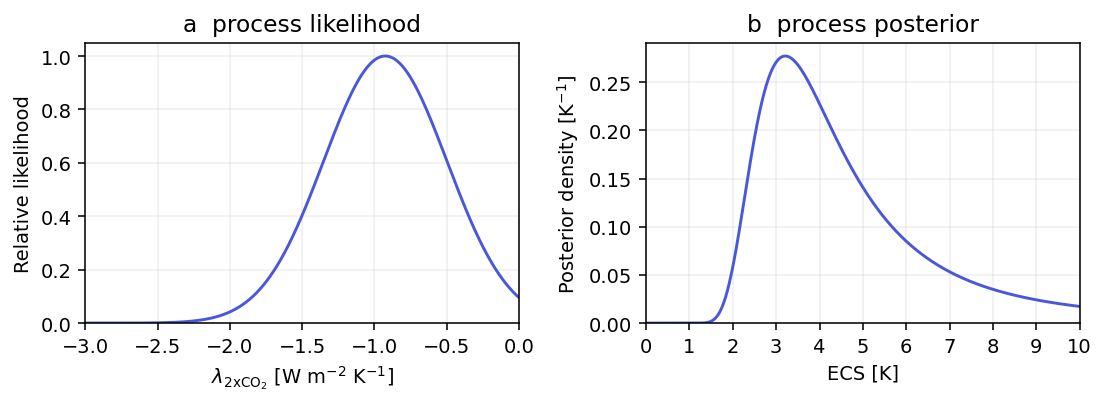

In [17]:
feedback_label = r"$\lambda_{\mathrm{2xCO_2}}$ [W m$^{-2}$ K$^{-1}$]"

def format_pair(axes):
    for ax, xlabel, limits, ticks in zip(axes,
            [feedback_label, "ECS [K]"], [(-3, 0), (0, 10)],
            [np.arange(-3, 0.01, 0.5), np.arange(0, 11)]):
        ax.set(xlabel=xlabel, xlim=limits, xticks=ticks)
        ax.grid(alpha=0.2)

def plot_likelihoods(result, evidence, name):
    fig, axes = plt.subplots(1, 2, figsize=(8, 3))
    for ax, parameter, letter in zip(axes, ("lambda", "ECS"), "ab"):
        for line in evidence:
            ax.plot(result["grids"][parameter], result["curves"][line][parameter],
                    color=evidence_colors[line], label=line, lw=1.5)
        ax.set(ylim=(0, 1.05), title=f"{letter}  {'radiative feedback' if parameter == 'lambda' else 'ECS'}")
    axes[0].set_ylabel("Relative likelihood")
    axes[0].legend(frameon=False, fontsize=9)
    format_pair(axes)
    finish_figure(fig, name)

## process: feedback likelihood on the left, ECS posterior density on the right
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].plot(likelihoods["grids"]["lambda"], likelihoods["curves"]["Process"]["lambda"], color=evidence_colors["Process"])
axes[1].plot(likelihoods["grids"]["ECS"], process_posterior["ECS"], color=evidence_colors["Process"])
axes[0].set(ylabel="Relative likelihood", title="a  process likelihood", ylim=(0, 1.05))
axes[1].set(ylabel=r"Posterior density [K$^{-1}$]", title="b  process posterior", ylim=(0, None))
format_pair(axes)
finish_figure(fig, "fig_process_likely")

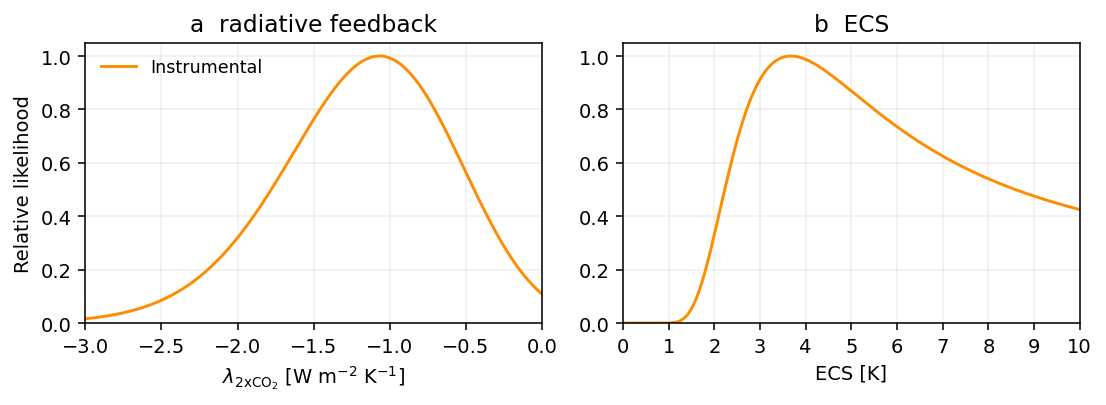

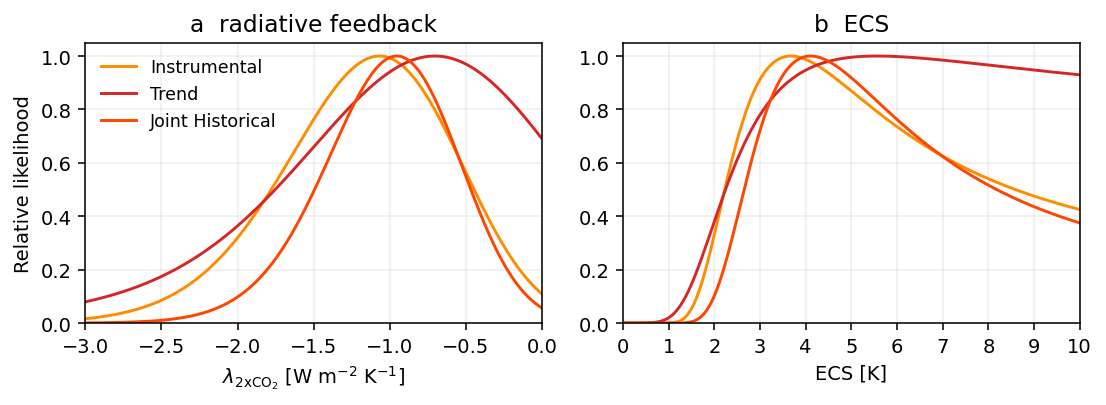

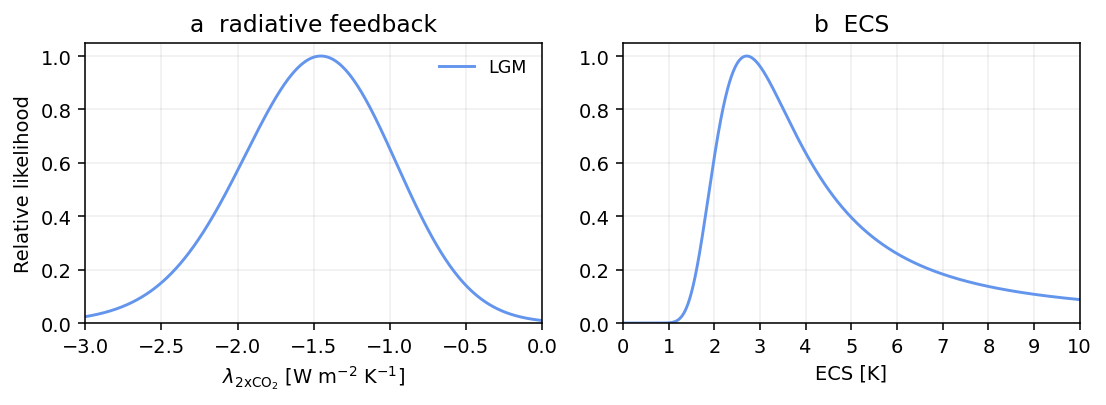

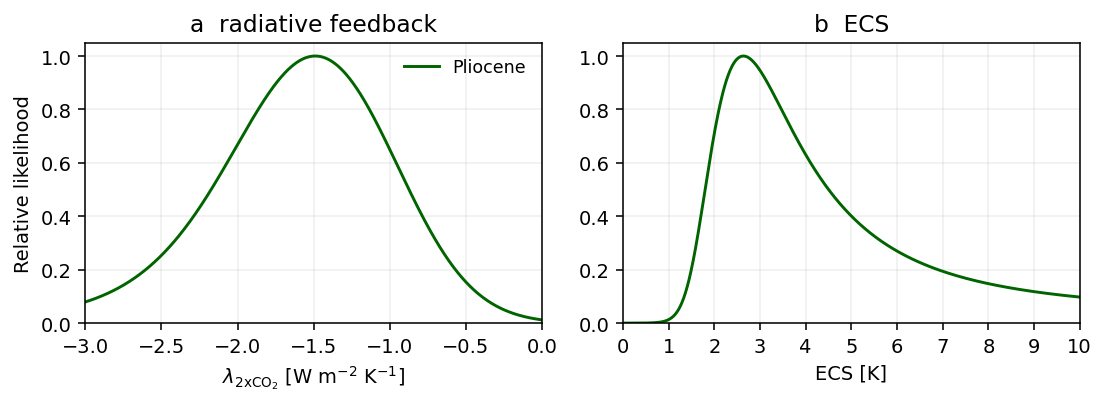

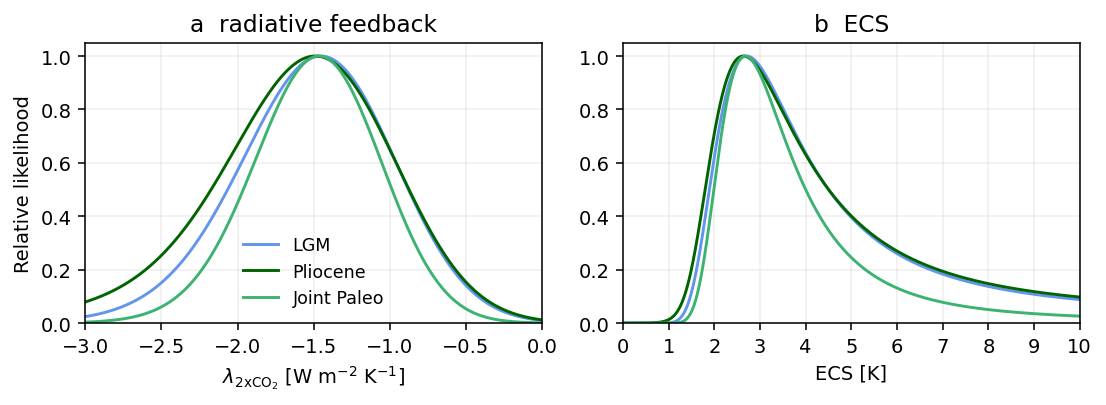

In [18]:
plot_likelihoods(likelihoods, ["Instrumental"], "fig_inst_likely")
plot_likelihoods(likelihoods, ["Instrumental", "Trend", "Joint Historical"], "fig_joint_hist")
plot_likelihoods(likelihoods, ["LGM"], "fig_lgm_likely")
plot_likelihoods(likelihoods, ["Pliocene"], "fig_plio_likely")
plot_likelihoods(likelihoods, ["LGM", "Pliocene", "Joint Paleo"], "fig_joint_paleo")

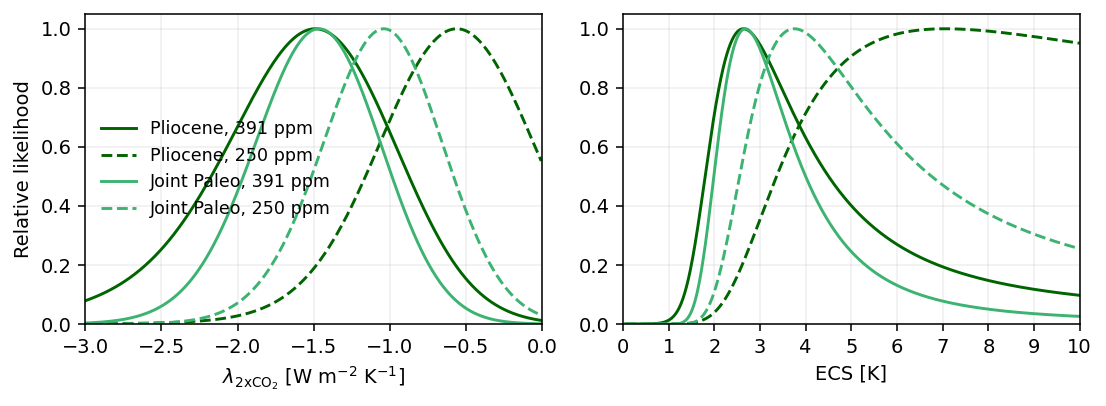

In [19]:
## also show the lower-CO2 Pliocene sensitivity discussed in the paper
low_co2_likelihoods = calculate_likelihoods(low_pliocene_co2["data"])
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for ax, parameter in zip(axes, ("lambda", "ECS")):
    for name in ("Pliocene", "Joint Paleo"):
        for co2, result, ls in [(391, likelihoods, "-"), (250, low_co2_likelihoods, "--")]:
            ax.plot(result["grids"][parameter], result["curves"][name][parameter],
                    color=evidence_colors[name], ls=ls, label=f"{name}, {co2} ppm")
    ax.set_ylim(0, 1.05)
axes[0].set_ylabel("Relative likelihood")
axes[0].legend(frameon=False, fontsize=9)
format_pair(axes)
finish_figure(fig, "fig_low_pliocene_co2")

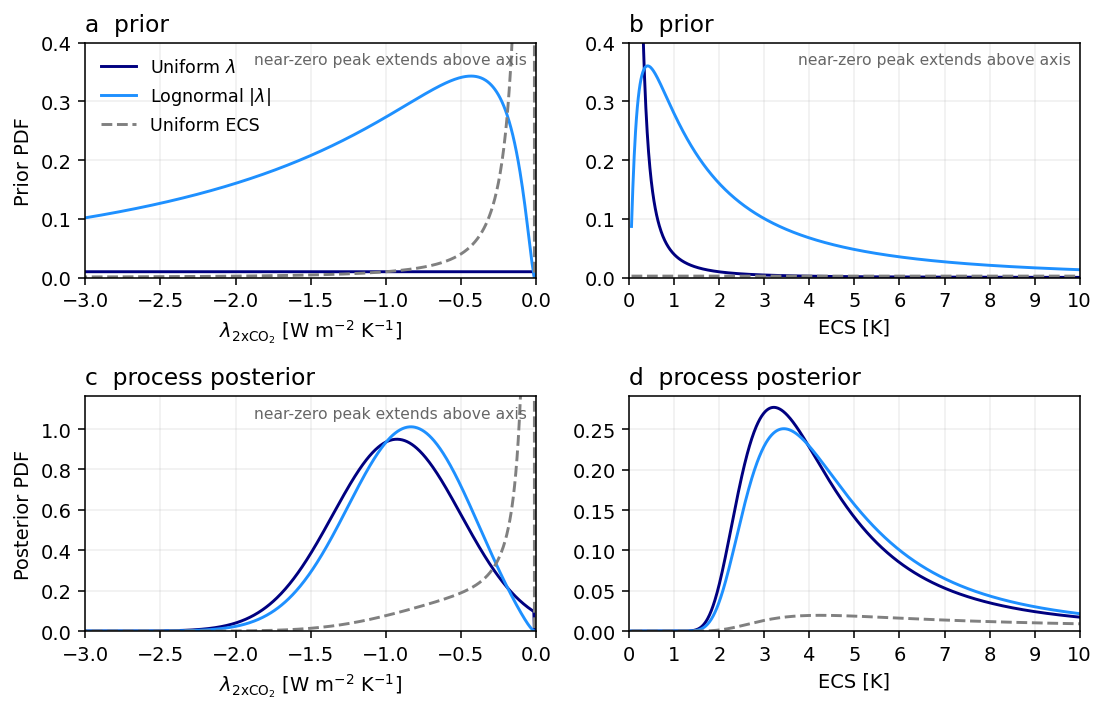

In [20]:
prior_labels = {"uniform_lambda": r"Uniform $\lambda$",
                "lognormal_lambda": r"Lognormal $|\lambda|$", "uniform_ECS": "Uniform ECS"}
prior_colors = {"uniform_lambda": "navy", "lognormal_lambda": "dodgerblue", "uniform_ECS": "gray"}
fig, axes = plt.subplots(2, 2, figsize=(8, 5.2))
for row, kind in enumerate(("prior", "posterior")):
    for col, parameter in enumerate(("lambda", "ECS")):
        for prior, values in process_pdfs.items():
            axes[row, col].plot(likelihoods["grids"][parameter], values[kind][parameter],
                label=prior_labels[prior], color=prior_colors[prior],
                ls="--" if prior == "uniform_ECS" else "-")
        title = "prior" if row == 0 else "process posterior"
        axes[row, col].set_title(f"{'abcd'[2*row+col]}  {title}", loc="left")
        axes[row, col].set_ylim(bottom=0)
    axes[row, 0].set_ylabel("Prior PDF" if row == 0 else "Posterior PDF")
    format_pair(axes[row])
axes[0, 0].legend(frameon=False, fontsize=9)
## zoom in on the main curves, as in the paper; all PDFs keep their full normalization
for ax in axes[0]:
    ax.set_ylim(0, 0.4)
axes[1, 0].set_ylim(0, 1.15 * max(
    process_pdfs[p]["posterior"]["lambda"].max()
    for p in ("uniform_lambda", "lognormal_lambda")))
axes[0, 0].text(.98, .96, "near-zero peak extends above axis", transform=axes[0, 0].transAxes,
                ha="right", va="top", fontsize=8, color="0.4")
axes[0, 1].text(.98, .96, "near-zero peak extends above axis", transform=axes[0, 1].transAxes,
                ha="right", va="top", fontsize=8, color="0.4")
axes[1, 0].text(.98, .96, "near-zero peak extends above axis", transform=axes[1, 0].transAxes,
                ha="right", va="top", fontsize=8, color="0.4")
finish_figure(fig, "fig_prior_process_comparison")

In [21]:
## smoothing is only for displaying PDFs and estimating modes;
## all reported percentiles and means come directly from the Stan draws
def posterior_density(draws, grid, negative=False, bandwidth=0.12):
    positive = -draws if negative else draws
    x = -np.asarray(grid) if negative else np.asarray(grid)
    kde = gaussian_kde(np.log(positive), bw_method=bandwidth)
    return kde(np.log(x)) / x

def posterior_summary(draws, negative=False):
    positive = -draws if negative else draws
    grid = np.geomspace(*np.quantile(positive, [.001, .999]), 1_000)
    density = posterior_density(positive, grid, bandwidth=0.05)
    mode = grid[np.argmax(density)] * (-1 if negative else 1)
    return [*np.quantile(draws, [.05, .17, .50, .83, .95]), np.mean(draws), mode]

plot_rows = [
    ("Baseline", "baseline", "navy"),
    ("Excl. Process", "no_process", "royalblue"),
    ("Excl. Instrumental", "without_instrumental", "darkorange"),
    ("Excl. Trend", "without_trend", "tab:red"),
    ("Excl. Joint Historical", "without_joint_historical", "orangered"),
    ("Excl. LGM", "without_lgm", "cornflowerblue"),
    ("Excl. Pliocene", "without_pliocene", "darkgreen"),
    ("Excl. Joint Paleo", "no_paleo", "mediumseagreen"),
    ("Lognormal Prior", "lognormal_lambda", "navy"),
    ("Uniform ECS Prior", "uniform_ECS", "navy"),
]
summary_rows = plot_rows + [("Pliocene CO2 = 250 ppm", "low_pliocene_co2", "gray")]
columns = ["5th", "17th", "50th", "83rd", "95th", "Mean", "Mode"]
ECS_summary = pd.DataFrame({label: posterior_summary(results[name]["ECS"])
    for label, name, _ in summary_rows}, index=columns).T
lambda_summary = pd.DataFrame({label: posterior_summary(results[name]["lamb"], negative=True)
    for label, name, _ in summary_rows}, index=columns).T
print("ECS [K]")
display(ECS_summary)
print("Feedback [W m-2 K-1]")
display(lambda_summary)
ECS_summary.to_csv(output_dir / "ECS_summary.csv")
lambda_summary.to_csv(output_dir / "lambda_summary.csv")

ECS [K]


,5th,17th,50th,83rd,95th,Mean,Mode
Baseline,2.514018,2.842924,3.450555,4.320077,5.281677,3.615723,3.127834
Excl. Process,2.220673,2.553159,3.164437,4.099560,5.191702,3.424802,2.932159
Excl. Instrumental,2.369733,2.719095,3.366938,4.366453,5.557236,3.596421,3.084238
Excl. Trend,2.392612,2.717221,3.290378,4.153536,5.089487,3.464920,2.966151
Excl. Joint Historical,2.254461,2.592244,3.221046,4.202767,5.334295,3.451068,2.849426
Excl. LGM,2.542905,2.914790,3.599440,4.639856,5.789119,3.819710,3.243807
Excl. Pliocene,2.556523,2.917836,3.606824,4.653002,5.880059,3.838398,3.370249
Excl. Joint Paleo,2.676280,3.157105,4.147148,5.899252,8.320650,4.710849,3.523206
Lognormal Prior,2.572854,2.927689,3.554770,4.485016,5.527091,3.737165,3.278302
Uniform ECS Prior,2.682700,3.080795,3.853360,5.098768,6.734813,4.502635,3.423445


Feedback [W m-2 K-1]


,5th,17th,50th,83rd,95th,Mean,Mode
Baseline,-1.549384,-1.375932,-1.139226,-0.907505,-0.737627,-1.141254,-1.147092
Excl. Process,-1.776171,-1.549666,-1.246550,-0.954728,-0.750924,-1.251860,-1.257806
Excl. Instrumental,-1.626957,-1.429945,-1.165009,-0.899144,-0.710384,-1.165941,-1.222251
Excl. Trend,-1.625133,-1.440131,-1.187236,-0.942673,-0.765167,-1.190520,-1.174472
Excl. Joint Historical,-1.699923,-1.497520,-1.212988,-0.933488,-0.738710,-1.215583,-1.195025
Excl. LGM,-1.526790,-1.345017,-1.089344,-0.839288,-0.667086,-1.092943,-1.072880
Excl. Pliocene,-1.531663,-1.344542,-1.091433,-0.841626,-0.663427,-1.093681,-1.054733
Excl. Joint Paleo,-1.463993,-1.243259,-0.946976,-0.659037,-0.462258,-0.953033,-0.906493
Lognormal Prior,-1.510277,-1.340220,-1.101906,-0.870204,-0.699389,-1.104919,-1.074421
Uniform ECS Prior,-1.447400,-1.266863,-1.010884,-0.760600,-0.566075,-1.011076,-0.985521


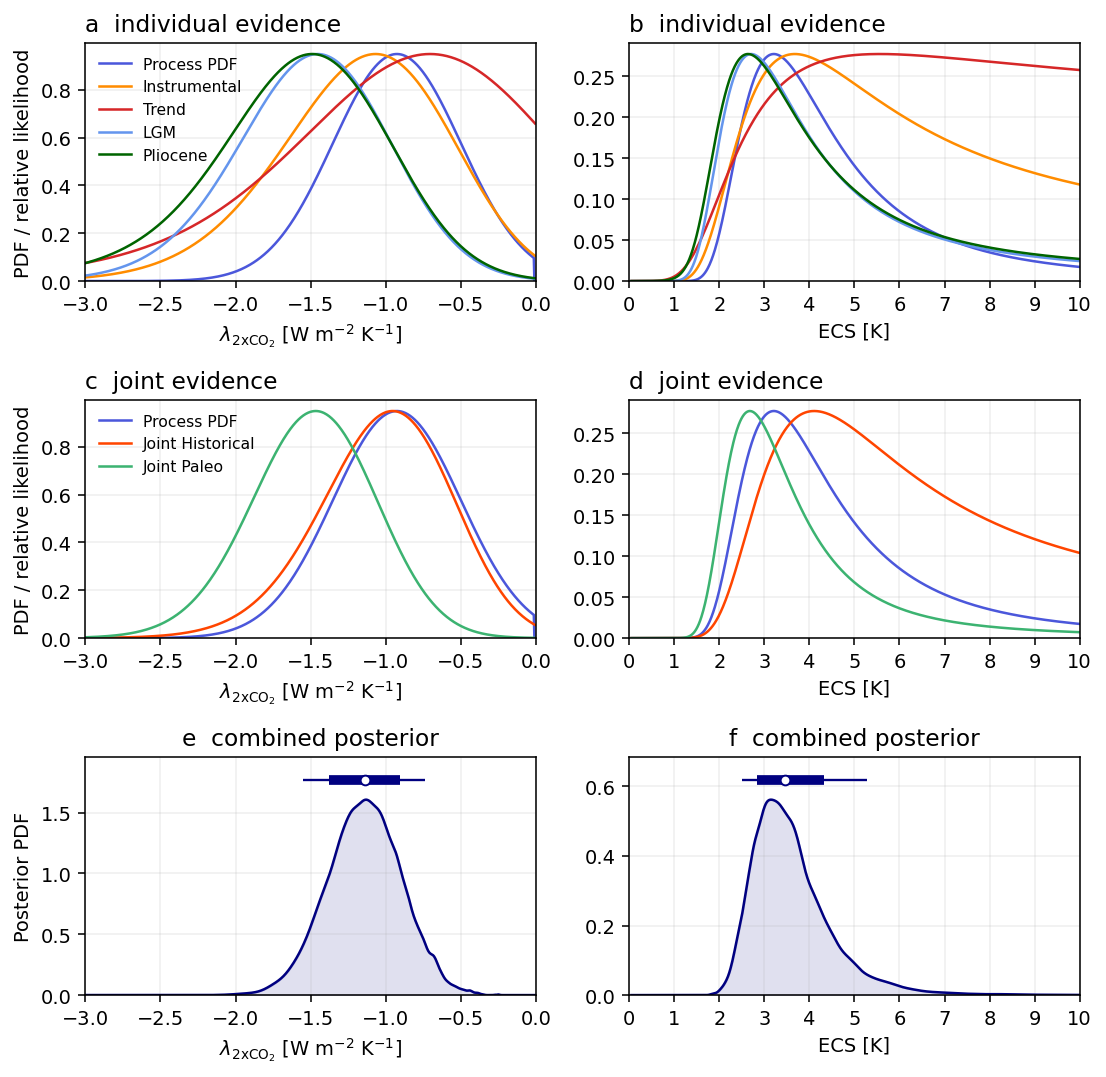

In [22]:
fig, axes = plt.subplots(3, 2, figsize=(8, 7.8))
for row, evidence in enumerate((individual_evidence, ("Process", "Joint Historical", "Joint Paleo"))):
    for col, parameter in enumerate(("lambda", "ECS")):
        ax = axes[row, col]
        for name in evidence:
            y = process_posterior[parameter] if name == "Process" else (
                likelihoods["curves"][name][parameter] * process_posterior[parameter].max())
            ax.plot(likelihoods["grids"][parameter], y, color=evidence_colors[name],
                    label="Process PDF" if name == "Process" else name, lw=1.3)
        ax.set_ylim(bottom=0)
        title = "individual evidence" if row == 0 else "joint evidence"
        ax.set_title(f"{'abcd'[2*row+col]}  {title}", loc="left")
    axes[row, 0].set_ylabel("PDF / relative likelihood")
    axes[row, 0].legend(frameon=False, fontsize=8)

## the combined posterior comes from Stan and retains all shared uncertainties
for col, (parameter, draw_name) in enumerate((("lambda", "lamb"), ("ECS", "ECS"))):
    ax = axes[2, col]
    grid, draws = likelihoods["grids"][parameter], baseline[draw_name]
    density = posterior_density(draws, grid, negative=(parameter == "lambda"))
    ax.plot(grid, density, color="navy", lw=1.3)
    ax.fill_between(grid, density, color="navy", alpha=0.12)
    q05, q17, median, q83, q95 = np.quantile(draws, [.05, .17, .5, .83, .95])
    y = density.max()*1.10
    ax.hlines(y, q05, q95, color="navy", lw=1.2)
    ax.hlines(y, q17, q83, color="navy", lw=5)
    ax.plot(median, y, "o", mfc="white", mec="navy", ms=5)
    ax.set(ylim=(0, density.max()*1.22), title=f"{'ef'[col]}  combined posterior")
axes[2, 0].set_ylabel("Posterior PDF")
for row in axes:
    format_pair(row)
finish_figure(fig, "fig_combined_likelihoods")

In the synthesis figure, process curves are PDFs and the other likelihoods are scaled to the process PDF's peak for display. The combined-posterior bars mark the median and central 66% and 90% intervals.

The sensitivity figure uses the same intervals. The range printed below spans the individual historical/paleo exclusions and the lognormal-prior test included here. Its test set is smaller than the draft paper's robustness calculation, which also included a likelihood-method sensitivity.

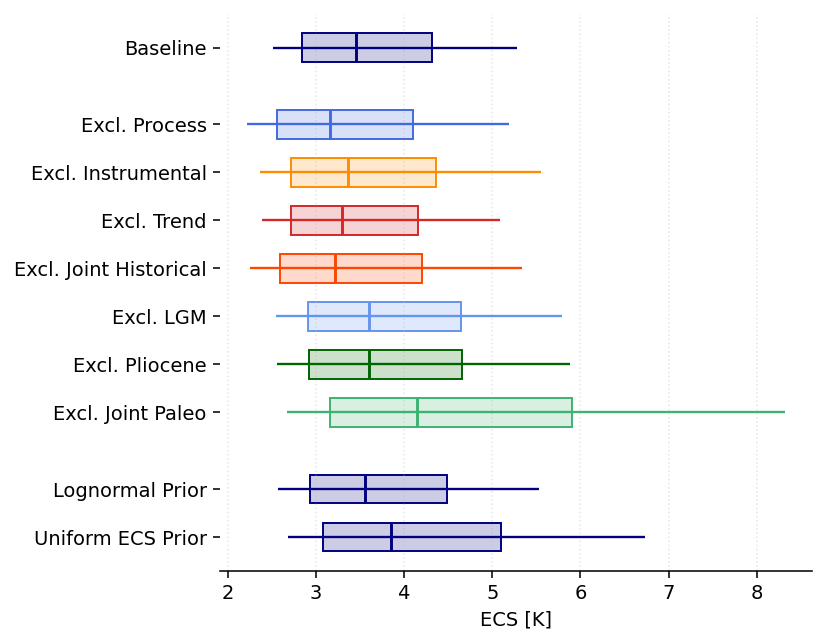

5–95% envelope for these selected tests: 2.3697331200000002–5.880058544999997 K


In [23]:
fig, ax = plt.subplots(figsize=(6, 4.7))
positions, y = [], 0
for label, name, color in plot_rows:
    positions.append(y)
    q05, q17, median, q83, q95 = ECS_summary.loc[label, columns[:5]]
    ax.hlines(y, q05, q95, color=color, lw=1.2)
    ax.add_patch(Rectangle((q17, y-.3), q83-q17, .6, facecolor=color, alpha=.2))
    ax.add_patch(Rectangle((q17, y-.3), q83-q17, .6, fill=False, edgecolor=color, lw=1))
    ax.vlines(median, y-.3, y+.3, color=color, lw=1.5)
    y += 1.6 if label in ("Baseline", "Excl. Joint Paleo") else 1
ax.set(yticks=positions, yticklabels=[row[0] for row in plot_rows],
       ylim=(positions[-1]+.7, -.7), xlabel="ECS [K]")
ax.grid(axis="x", alpha=.3, ls=":")
ax.spines[["top", "right", "left"]].set_visible(False)
finish_figure(fig, "fig_sensitivity_tests")

robust_rows = ["Excl. Instrumental", "Excl. Trend", "Excl. LGM", "Excl. Pliocene", "Lognormal Prior"]
print("5–95% envelope for these selected tests:",
      f"{ECS_summary.loc[robust_rows, '5th'].min()}–{ECS_summary.loc[robust_rows, '95th'].max()} K")